In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig, KalmanConfig, RollingOLSConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.models.kalman_hedge import KalmanHedge
from pairs_trading.models.rolling_ols_hedge import RollingOLSHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal
from pairs_trading.backtest.engine import BacktestEngine

First let's build a dataframe containing all the tickers that we want to test. Split between train and test sets.

In [2]:
tickers = ["IAU", "GDX", "GLD", "SLV", "XLF", "KBE", "SPY", "IVV"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.train_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.val_start, SplitConfig.val_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [3]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["XLF", "KBE"], ["SPY", "IVV"]]

First we run a hyperparameter search to find the optimal averaging window for rolling OLS

In [4]:
windows= np.arange(5, 450, 2)
rows = []
split = int(len(df_train) * 0.67)
df_window_train = df_train.iloc[:split]
df_window_val = df_train.iloc[split:]

for window in windows:
    for y, x in pairs:
        hedge_ols = OLSHedge()
        hedge_ols.fit(df_window_train[y], df_window_train[x])
        residuals_ols = hedge_ols.spread(df_window_val[y], df_window_val[x])
        zscores_ols = rolling_zscore(residuals_ols)
        signals_ols = generate_signal(zscores_ols)

        config = RollingOLSConfig(window=window)
        hedge_rolling_ols = RollingOLSHedge(config=config)
        hedge_rolling_ols.fit(df_window_train[y], df_window_train[x])
        betas, alphas, res = hedge_rolling_ols.transform(df_window_val[y], df_window_val[x])

        engine_rolling_ols = BacktestEngine()
        result_rolling_ols = engine_rolling_ols.run(df_window_val[y], df_window_val[x], signals_ols, betas)
        rows.append({"window": window, "pair": f"{x}/{y}", **result_rolling_ols.metrics})

df_results = pd.DataFrame(rows).set_index(["pair", "window"])

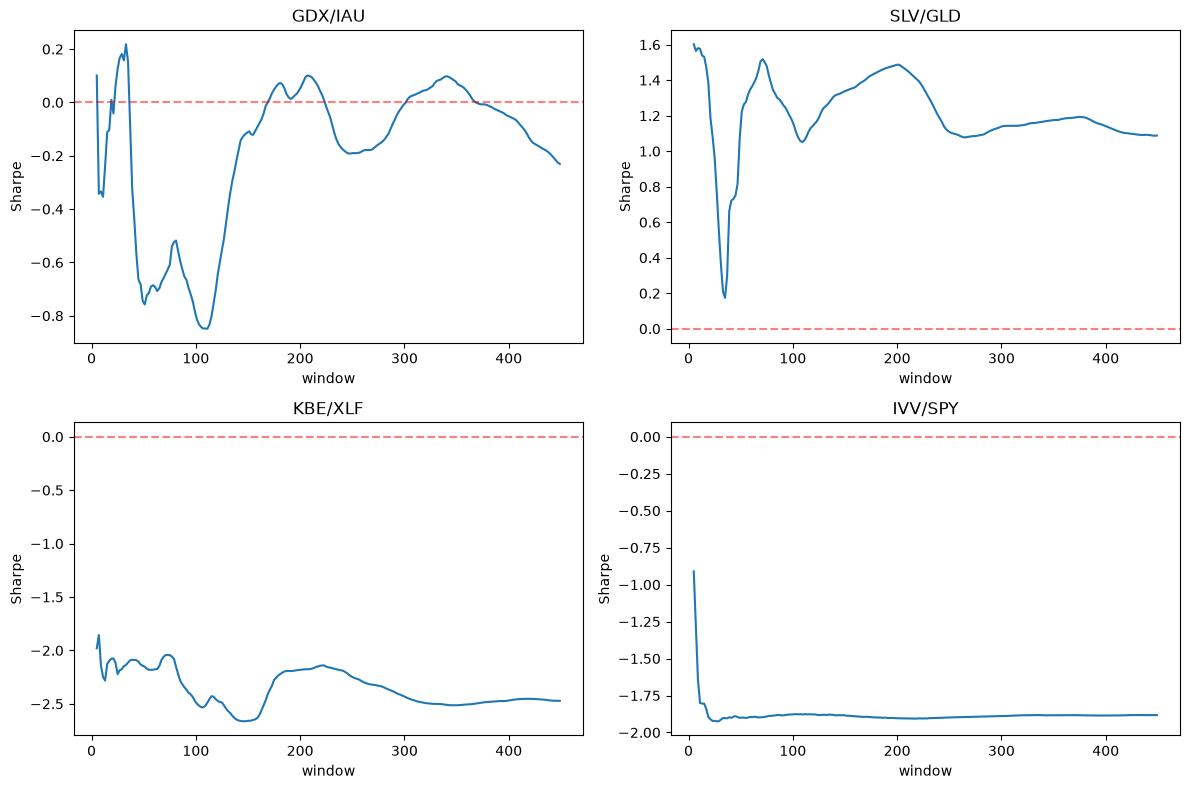

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (y, x) in enumerate(pairs):
    pair_data = df_results.loc[f"{x}/{y}"]
    axs[i].plot(pair_data.index, pair_data["sharpe"])
    axs[i].axhline(0, color="r", linestyle="--", alpha=0.5)
    axs[i].set_xlabel("window")
    axs[i].set_ylabel("Sharpe")
    axs[i].set_title(f"{x}/{y}")

plt.tight_layout()
plt.show()

While KBE/XLF and IVV/SPY have highly negative Sharpe ratios no matter the window size. Both GDX/IAU and SLV/GLD exhibit a peak at approximately 200 which we will use as the default window size.

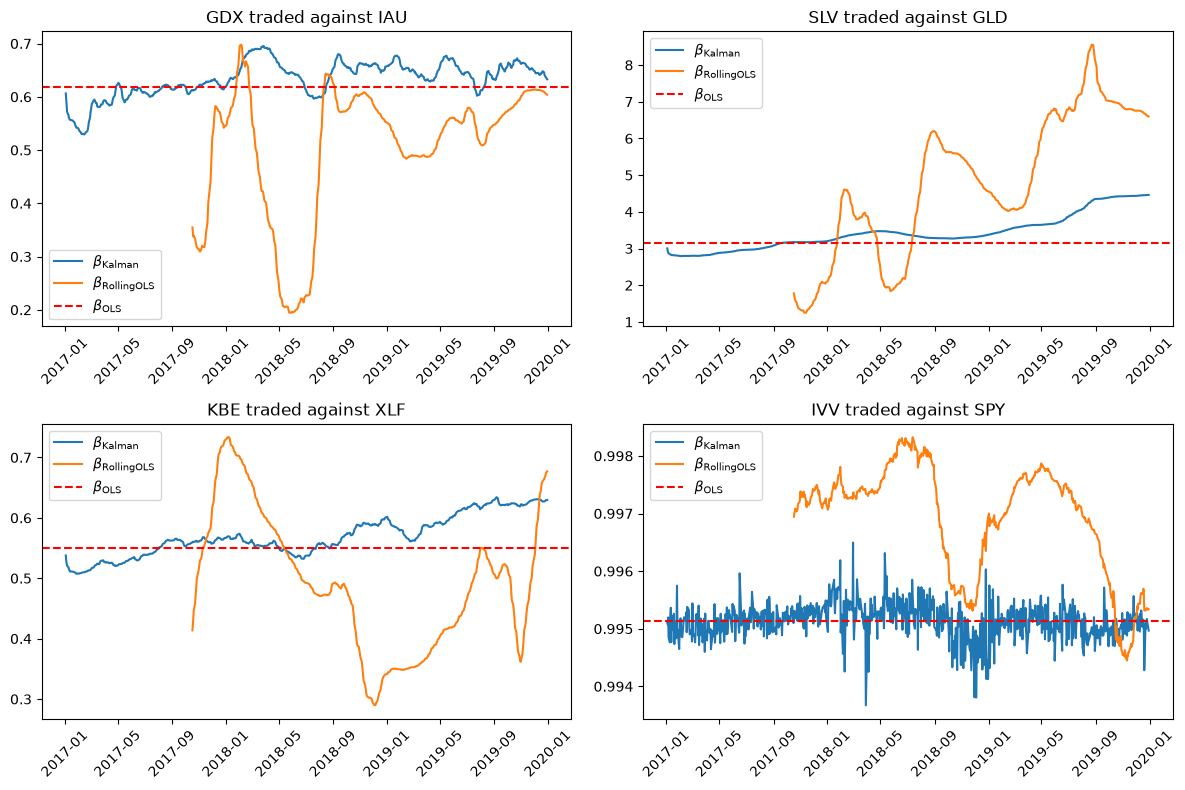

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])

    hedge_kalman = KalmanHedge()
    hedge_kalman.fit(df_train[y], df_train[x])

    hedge_rolling_ols = RollingOLSHedge()
    hedge_rolling_ols.fit(df_train[y], df_train[x])

    axs[i].plot(hedge_kalman.beta, label=r"$\beta_\mathrm{Kalman}$")
    axs[i].plot(hedge_rolling_ols.beta, label=r"$\beta_\mathrm{RollingOLS}$")

    axs[i].axhline(y=hedge_ols.beta, color='r', linestyle='--', label=r"$\beta_\mathrm{OLS}$")
    
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Final test results for trading GDX against IAU:
OLS sharpe: -0.21993088645080958
Kalman sharpe: -0.35570155082385985
Rolling OLS sharpe: 0.21350918329052085
OLS max_drawdown: 0.14992456642648652
Kalman max_drawdown: 0.20857663260471787
Rolling OLS max_drawdown: 0.07367751838541411
OLS hit_rate: 0.4574898785425101
Kalman hit_rate: 0.4574898785425101
Rolling OLS hit_rate: 0.5060728744939271
OLS average_holding_period: 21.363636363636363
Kalman average_holding_period: 21.363636363636363
Rolling OLS average_holding_period: 21.363636363636363
OLS n_trades: 11
Kalman n_trades: 11
Rolling OLS n_trades: 11
----------------------------------------


Final test results for trading SLV against GLD:
OLS sharpe: 0.15168047912055777
Kalman sharpe: 0.22898092476366638
Rolling OLS sharpe: 0.15839872179601053
OLS max_drawdown: 0.6222505037888113
Kalman max_drawdown: 0.7893137004690216
Rolling OLS max_drawdown: 0.5854558989365714
OLS hit_rate: 0.47619047619047616
Kalman hit_rate: 0.47619047619047616
Rol

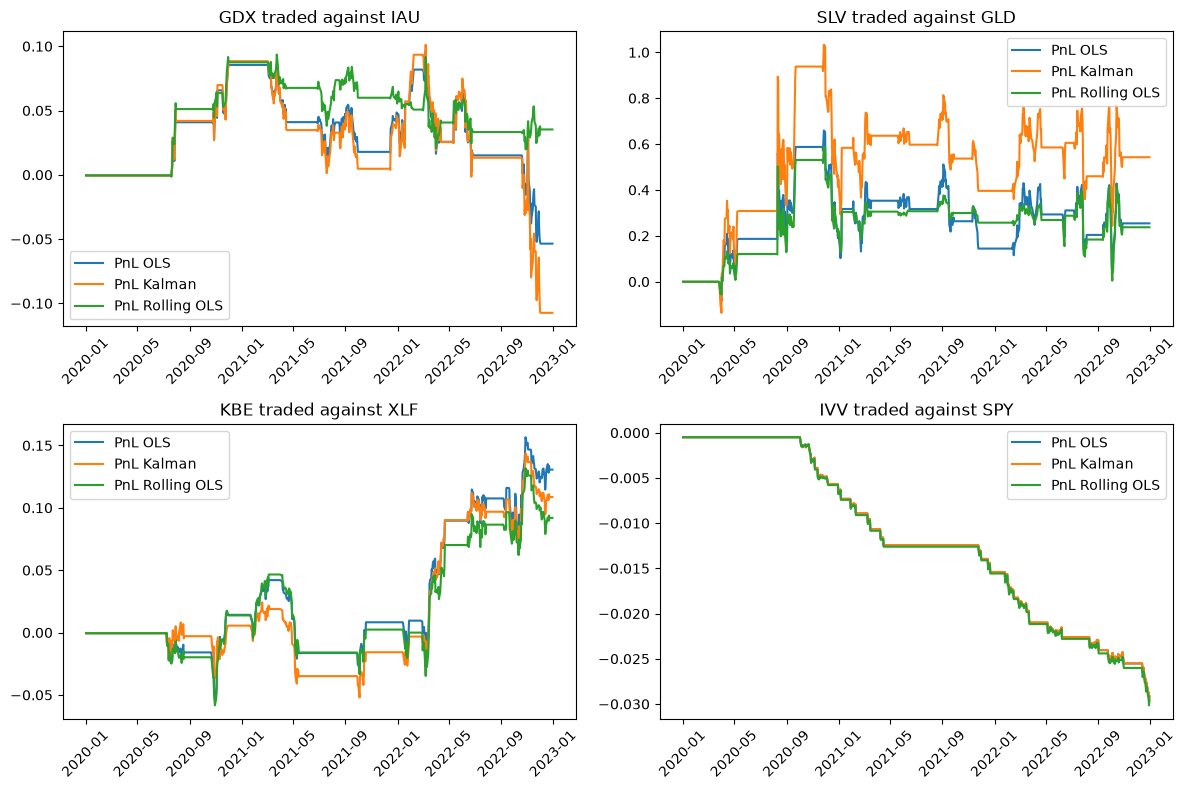

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])
    residuals_ols = hedge_ols.spread(df_test[y], df_test[x])
    zscores_ols = rolling_zscore(residuals_ols)
    signals = generate_signal(zscores_ols)
    hedge_ols_ratios = pd.Series(hedge_ols.beta, index=signals.index)
    engine_ols = BacktestEngine()
    result_ols = engine_ols.run(df_test[y], df_test[x], signals, hedge_ols_ratios)


    hedge_kalman = KalmanHedge()
    hedge_kalman.fit(df_train[y], df_train[x])
    betas, _, _ = hedge_kalman.transform(df_test[y], df_test[x])

    hedge_kalman_ratios = pd.Series(hedge_kalman.beta, index=signals.index)
    engine_kalman = BacktestEngine()
    result_kalman = engine_kalman.run(df_test[y], df_test[x], signals, hedge_kalman_ratios)

    hedge_rolling_ols = RollingOLSHedge()
    hedge_rolling_ols.fit(df_train[y], df_train[x])
    betas_roll_ols, _, _ = hedge_rolling_ols.transform(df_test[y], df_test[x])

    hedge_roll_ols_ratios = pd.Series(betas_roll_ols, index=signals.index)
    engine_roll_ols = BacktestEngine()
    result_roll_ols = engine_roll_ols.run(df_test[y], df_test[x], signals, hedge_roll_ols_ratios)
    

    print(f"Final test results for trading {x} against {y}:")
    for key in result_ols.metrics.keys():
        print(f"OLS {key}: {result_ols.metrics[key]}")
        print(f"Kalman {key}: {result_kalman.metrics[key]}")
        print(f"Rolling OLS {key}: {result_roll_ols.metrics[key]}")

    print("-"*40)
    print("\n")
    # axs[i].plot(result_ols.gross_pnl.cumsum(), label="Gross PnL OLS")
    axs[i].plot(result_ols.pnl.cumsum(), label="PnL OLS")
    # axs[i].plot(result_kalman.gross_pnl.cumsum(), label="Gross PnL Kalman")
    axs[i].plot(result_kalman.pnl.cumsum(), label="PnL Kalman")

    # axs[i].plot(result_roll_ols.gross_pnl.cumsum(), label="Gross PnL Rolling OLS")
    axs[i].plot(result_roll_ols.pnl.cumsum(), label="PnL Rolling OLS")
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()